In [1]:
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.io as sio
import pandas as pd


In [2]:
home_dir = "/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/"
manuscript_dir = home_dir + "Work/Manuscripts/2019_06 SO CMIP Comparison/"

plot_ver = '_v20' # this should be saved in the variable files, can check for it later

In [3]:
df = pd.read_csv(manuscript_dir + 'spreadsheets/Table_taylor_results' + plot_ver + '.csv',  index_col=[0])
df

,fgco2_correlation,fgco2_ratio,fgco2_norm_error,spco2_correlation,spco2_ratio,spco2_norm_error,dissic_correlation,dissic_ratio,dissic_norm_error,tos_correlation,...,sos_norm_error,talk_correlation,talk_ratio,talk_norm_error,mld_correlation,mld_ratio,mld_norm_error,intpp_correlation,intpp_ratio,intpp_norm_error
Model_Name,,,,,,,,,,,,,,,,,,,,,
CESM1_BGC,0.944810,0.989128,0.330603,0.959115,0.670002,0.404581,0.966307,1.101481,0.290727,0.999344,...,0.935216,0.981040,0.695064,0.345459,0.988753,0.688285,0.335632,0.904995,2.051823,1.223192
CMCC_CESM,-0.472446,1.776609,2.415583,-0.541379,1.774212,2.463508,0.872650,0.926841,0.491344,0.998637,...,1.506144,0.933768,1.139197,0.412648,0.972390,0.519030,0.509895,0.548576,1.597988,1.341764
CNRM_CM5,-0.836466,0.820512,1.745251,NaN,NaN,NaN,0.826853,0.700622,0.576410,0.994216,...,0.353374,0.852813,0.353293,0.722655,0.996802,0.578991,0.425384,0.699046,1.110429,0.824968
CanESM2,-0.763573,4.676092,5.477857,-0.801702,0.852538,1.758916,0.798618,0.835364,0.602959,0.994493,...,0.334032,0.952635,0.424210,0.609688,0.997428,0.646151,0.358515,0.902616,0.694603,0.478073
GFDL_ESM2G,-0.807751,0.518032,1.450945,-0.886444,0.654953,1.609386,0.898851,0.828995,0.443787,0.997891,...,0.187582,0.855111,0.206156,0.830619,0.982287,0.800474,0.261089,0.917802,2.385719,1.520664
GFDL_ESM2M,-0.564347,0.618620,1.442540,-0.677562,0.716811,1.576447,0.915086,1.046671,0.424185,0.996732,...,0.397551,0.708150,0.229442,0.853045,0.987915,0.679817,0.344889,0.882545,2.448603,1.635131
GISS_E2_H_CC,0.658183,1.149037,0.898740,0.693784,1.565013,1.130356,0.968771,2.005525,1.065993,0.987954,...,2.522922,NaN,NaN,NaN,0.948986,0.962116,0.315592,0.902252,1.078697,0.465912
GISS_E2_R_CC,0.333765,1.139179,1.239876,0.499566,1.129279,1.070968,0.885981,1.334994,0.645484,0.994936,...,0.439535,NaN,NaN,NaN,0.960961,1.594614,0.691427,0.918205,1.450458,0.663470
HadGEM2_CC,0.766652,1.161202,0.753602,0.801621,1.882863,1.235512,0.983422,1.282139,0.349446,0.991575,...,0.607867,0.689946,0.612912,0.727948,0.988131,0.790576,0.250250,0.929466,4.351144,3.441508


In [12]:
for key in df.keys():
    print(key)
    print(str(round(max(df[key]),2)) + ' ' + str(round(min(df[key]),2)), end='')
    print(' ')

fgco2_correlation
0.94 -0.98 
fgco2_ratio
6.29 0.25 
fgco2_norm_error
7.21 0.33 
spco2_correlation
0.96 -0.99 
spco2_ratio
3.51 0.3 
spco2_norm_error
2.89 0.4 
dissic_correlation
0.99 0.75 
dissic_ratio
2.01 0.32 
dissic_norm_error
1.07 0.24 
tos_correlation
1.0 0.99 
tos_ratio
2.58 0.83 
tos_norm_error
1.59 0.04 
sos_correlation
1.0 0.85 
sos_ratio
3.42 0.55 
sos_norm_error
2.52 0.13 
talk_correlation
0.98 -0.74 
talk_ratio
1.14 0.2 
talk_norm_error
1.46 0.21 
mld_correlation
1.0 0.92 
mld_ratio
1.59 0.44 
mld_norm_error
0.69 0.11 
intpp_correlation
0.94 0.42 
intpp_ratio
5.75 0.31 
intpp_norm_error
5.12 0.41 


In [4]:
column_names = df.keys()

df_max_min = np.zeros((2,len(column_names)))
for cn in range(0, len(column_names)):
    if 'ratio' in column_names[cn]:
        df_max_min[0,cn] = max(abs(df[column_names[cn]].values-1))
        df_max_min[1,cn] = min(abs(df[column_names[cn]].values-1))
    else:
        df_max_min[0,cn] = max(df[column_names[cn]].values)
        df_max_min[1,cn] = min(df[column_names[cn]].values)
df_max_min

array([[ 9.44809836e-01,  5.28532990e+00,  7.21092667e+00,
         9.59114702e-01,  2.50511793e+00,  2.89350319e+00,
         9.86210716e-01,  1.00552479e+00,  1.07167002e+00,
         9.99343810e-01,  1.58122821e+00,  1.58796732e+00,
         9.96628874e-01,  2.41602517e+00,  2.52292235e+00,
         9.84409803e-01,  8.01613163e-01,  1.46430490e+00,
         9.98816699e-01,  5.94614291e-01,  6.91427285e-01,
         9.41514822e-01,  4.74779849e+00,  5.12204792e+00],
       [-9.80049004e-01,  9.10430335e-03,  3.30603162e-01,
        -9.87862698e-01,  2.07998964e-03,  4.04580559e-01,
         7.47389998e-01,  1.54792485e-02,  2.41135608e-01,
         9.86296429e-01,  3.25820476e-03,  4.11070017e-02,
         8.49505203e-01,  3.08131715e-03,  1.33459391e-01,
        -7.35558931e-01,  5.23072343e-02,  2.05760878e-01,
         9.19296671e-01,  3.78840831e-02,  1.07713778e-01,
         4.20734618e-01,  2.32121201e-02,  4.08004020e-01]])

In [29]:
abs(df[column_names[1]].values-1)

array([0.01087225, 0.77660917, 0.17948778, 3.67609201, 0.48196759,
       0.38138048, 0.14903696, 0.13917918, 0.16120217, 0.057657  ,
       0.44515198, 0.58756188, 0.40553364, 0.21533478, 0.14338016,
       1.59261184, 2.1030912 , 5.2853299 , 0.96832288, 0.0091043 ,
       0.13492771, 0.42532736, 0.3759762 , 0.56193803, 0.15666299,
       0.02817367, 0.16815032, 0.05943051, 0.40209886, 0.15302748,
       0.41121747, 0.30533468, 0.27394132, 0.41623254, 0.34760513,
       0.88525051, 0.02591714, 0.4882052 , 0.71700793, 0.75060301,
       0.75088944, 0.64125422, 0.74320482, 0.28611031])

In [21]:
abs(df_max_min[0,cn]-1)

5.28532990264111

In [22]:
abs(df_max_min[1,cn]-1)

0.750889438382558

0.249110561617442

In [38]:
cn=16
print(column_names[cn])
print(df_max_min[1,cn])
print(df_max_min[0,cn])
range_val = df_max_min[0,cn] - df_max_min[1,cn]

# rgba_color = cmap(norm(.9),bytes=True) 
# print(rgba_color[0]/255)
# print(rgba_color[1]/255)
# print(rgba_color[2]/255)

print(range_val)

print(df[column_names[cn]].values)

talk_ratio
0.05230723426949002
0.1391965010554701
0.08688926678598008
[0.69506412 1.1391965  0.35329334 0.4242101  0.20615612 0.22944167
        nan        nan 0.61291187 0.56262971 0.44542711 0.40786161
 0.68490945        nan        nan 0.58582573 0.56210659 0.94437229
 1.06083128 0.94769277 0.19838684 0.61666987 0.60086628 0.2592445
 0.46618488 0.5014805  0.39351861 0.42940981        nan 0.48731954
 0.27731563        nan        nan 1.09926242 0.30566134 0.41373885
 0.50130835 0.67959841 0.29395011 0.26304729 0.49262789 0.62852615
 0.24545505 0.34840409]


### Table 2 - model correlations

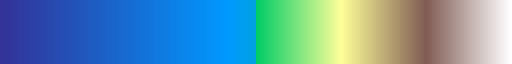

In [44]:
colors_undersea = plt.cm.terrain(np.linspace(0, 0.17, 256))
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
all_colors = np.vstack((colors_undersea, colors_land))
terrain_map = mpl.colors.LinearSegmentedColormap.from_list(
    'terrain_map', all_colors)
terrain_map

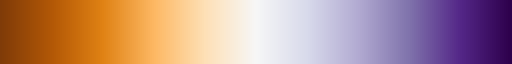

In [37]:
cmap

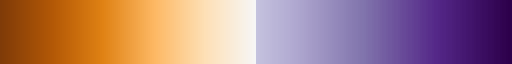

In [5]:
colors_bad= plt.cm.PuOr(np.linspace(0, 0.5, 256))
colors_good = plt.cm.PuOr(np.linspace(0.65, 1, 256))
all_colors = np.vstack((colors_bad, colors_good))
corr_map = mpl.colors.LinearSegmentedColormap.from_list(
    'corr_map', all_colors)
corr_map

In [6]:
column_names = df.keys()

df_max_min = np.zeros((2,len(column_names)))
for cn in range(0, len(column_names)):
    if 'ratio' in column_names[cn]:
        df_max_min[0,cn] = max(abs(df[column_names[cn]].values-1))
        df_max_min[1,cn] = min(abs(df[column_names[cn]].values-1))
    else:
        df_max_min[0,cn] = max(df[column_names[cn]].values)
        df_max_min[1,cn] = min(df[column_names[cn]].values)
df_max_min

# Don't need to recreate every part of the table, just the main numbers, putting the proper cell colors in pace. 
cmap = corr_map
cmap_flipped = mpl.colormaps["PuOr_r"]


# norm_corr = mpl.colors.Normalize(vmin=-0.6, vmax=1.6)  # want 0 to be the best here. 1x below 0, 3x above. 
# norm_ratio = mpl.colors.Normalize(vmin=-3, vmax=9)
# norm_error = mpl.colors.Normalize(vmin=-3.5, vmax=10.5)


column_names = df.keys()
num_models = df.shape[0]
cmip6_first=0
state_estimate_first = 0
for m in range(0, num_models):
    mod_name = df.index[m]
    mod_values = df.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
        if cmip6_first==0:
            cmip6_first=1
            print("\multicolumn{1}{l}{\\textbf{CMIP6}} \\\\ \midrule")
    if "SOSE" in mod_name_updated:
        if state_estimate_first==0:
            state_estimate_first=1
            print("\multicolumn{1}{l}{\\textbf{State Estimates}} \\\\ \midrule")

    no_data = 0
    print('\\textbf{' + mod_name_updated + '} ', end='')
    for idx, val in enumerate(mod_values):
        print('& ', end='')
        if np.isnan(val):
            print( '-' , end='')
        else:

            if  'correlation' in column_names[idx]:
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                if ('fgco2' in column_names[idx]) | ('spco2' in column_names[idx]):
                    norm_corr = mpl.colors.TwoSlopeNorm(vmin=df_max_min[1,idx] - range_val*.3, vcenter=0.65, vmax=df_max_min[0,idx]+range_val*.2)
                else:
                    norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)

                rgba_color = cmap(norm_corr(val),bytes=True) 
            elif 'ratio' in column_names[idx]:
                # rgba_color = [0,0,0]

                # # for ratio, we want better to be closer to 1. 
                val_color = abs(val - 1)
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)
                rgba_color = cmap_flipped(norm_corr(val_color),bytes=True) 
            elif 'error' in column_names[idx]:
                range_val = df_max_min[0,idx] - df_max_min[1,idx]

                norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.3)
                rgba_color = cmap_flipped(norm_corr(val),bytes=True) 

                # rgba_color = cmap_flipped(norm_error(val),bytes=True) # error is flipped, so closer to 0 is better
            else:
                rgba_color = [0,0,0]
                
            r = rgba_color[0]/255
            g = rgba_color[1]/255
            b = rgba_color[2]/255
            print('\cellcolor[rgb]{' + str(r.round(3)) + ',' + str(g.round(3)) + ','  + str(b.round(3)) + '}' + str(val.round(1)) + ' ', end='')
    print('\\\\', end='')

    print('')



\textbf{CESM1-BGC} & \cellcolor[rgb]{0.494,0.439,0.667}0.9 & \cellcolor[rgb]{0.478,0.416,0.655}1.0 & \cellcolor[rgb]{0.478,0.416,0.655}0.3 & \cellcolor[rgb]{0.49,0.427,0.663}1.0 & \cellcolor[rgb]{0.631,0.596,0.773}0.7 & \cellcolor[rgb]{0.478,0.416,0.655}0.4 & \cellcolor[rgb]{0.439,0.345,0.624}1.0 & \cellcolor[rgb]{0.576,0.533,0.729}1.1 & \cellcolor[rgb]{0.545,0.502,0.706}0.3 & \cellcolor[rgb]{0.376,0.239,0.573}1.0 & \cellcolor[rgb]{0.776,0.765,0.875}1.4 & \cellcolor[rgb]{0.765,0.753,0.867}0.4 & \cellcolor[rgb]{0.475,0.404,0.651}1.0 & \cellcolor[rgb]{0.863,0.871,0.925}1.9 & \cellcolor[rgb]{0.839,0.847,0.918}0.9 & \cellcolor[rgb]{0.38,0.239,0.573}1.0 & \cellcolor[rgb]{0.839,0.847,0.918}0.7 & \cellcolor[rgb]{0.608,0.569,0.753}0.3 & \cellcolor[rgb]{0.475,0.404,0.651}1.0 & \cellcolor[rgb]{0.961,0.961,0.965}0.7 & \cellcolor[rgb]{0.882,0.89,0.933}0.3 & \cellcolor[rgb]{0.431,0.333,0.616}0.9 & \cellcolor[rgb]{0.729,0.71,0.843}2.1 & \cellcolor[rgb]{0.686,0.655,0.812}1.2 \\
\textbf{CMCC-CESM} & \

In [ ]:
('fgco2' in column_names[idx]) | ('spco2' in column_names[idx])

True

In [ ]:
for idx, val in enumerate(mod_values):
    print('& ', end='')
    if np.isnan(val):
        print( '-' , end='')
    else:

        if  'correlation' in column_names[idx]:
            range_val = df_max_min[0,idx] - df_max_min[1,idx]

            norm_corr = mpl.colors.Normalize(vmin=df_max_min[1,idx] - range_val*.3, vmax=df_max_min[0,idx]+range_val*.5)
            rgba_color = cmap(norm_corr(val),bytes=True) 
            break    
    

& 

In [ ]:
mpl.colors

1.9072392562141807

In [16]:
df2 = pd.read_csv(manuscript_dir + 'spreadsheets/ensemble_members' + plot_ver + '.csv',  index_col=[0])
df2

,Variant
Model_Name,
CESM1_BGC,r1i1p1
CMCC_CESM,r1i1p1
CNRM_CM5,r1i1p1
CanESM2,r1i1p1
GFDL_ESM2G,r1i1p1
GFDL_ESM2M,r1i1p1
GISS_E2_H_CC,r1i1p1
GISS_E2_R_CC,r1i1p1
HadGEM2_CC,r2i1p1


In [11]:
column_names = df2.keys()
num_models = df2.shape[0]

for m in range(0, 19):
    mod_name = df2.index[m]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    print(mod_values[0], end='')
    print(' &  x & ', end='')

    # try printing CMIP6 in the right 3 columns
    mod_name = df2.index[m+19]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    variant = mod_values[0].replace('_','-')
    print(variant, end='')
    print(' &  x ', end='')

    print('\\\\', end='')
    print('')

for m in range(38, 42):
    print(' &  & &  ', end='')
    mod_name = df2.index[m]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    variant = mod_values[0].replace('_','-')
    print(variant, end='')
    print(' &  x ', end='')
    print('\\\\', end='')
    print('')
    
for m in range(42, num_models):
    mod_name = df2.index[m]
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
    print('\\textbf{' + mod_name_updated + '} ', end='')
    print('& ', end='')
    print(mod_values[0], end='')
    print(' &  x ', end='')
    print('\\\\', end='')
    print('')

\textbf{CESM1-BGC} & r1i1p1 &  x & \textbf{ACCESS-ESM1-5 (6)} & r1i1p1f1-gn &  x \\
\textbf{CMCC-CESM} & r1i1p1 &  x & \textbf{AWI-ESM-1-REcoM (6)} & r1i1p1f1-gr1 &  x \\
\textbf{CNRM-CM5} & r1i1p1 &  x & \textbf{CESM2-WACCM (6)} & r1i1p1f1-gr &  x \\
\textbf{CanESM2} & r1i1p1 &  x & \textbf{CESM2 (6)} & r4i1p1f1-gn &  x \\
\textbf{GFDL-ESM2G} & r1i1p1 &  x & \textbf{CMCC-ESM2 (6)} & r1i1p1f1-gn &  x \\
\textbf{GFDL-ESM2M} & r1i1p1 &  x & \textbf{CNRM-ESM2-1 (6)} & r1i1p1f2-gn &  x \\
\textbf{GISS-E2-H-CC} & r1i1p1 &  x & \textbf{CanESM5-1 (6)} & r1i1p1f1-gn &  x \\
\textbf{GISS-E2-R-CC} & r1i1p1 &  x & \textbf{CanESM5-CanOE (6)} & r1i1p2f1-gn &  x \\
\textbf{HadGEM2-CC} & r2i1p1 &  x & \textbf{CanESM5 (6)} & r1i1p2f1-gn &  x \\
\textbf{HadGEM2-ES} & r2i1p1 &  x & \textbf{EC-Earth3-CC (6)} & r1i1p1f1-gn &  x \\
\textbf{IPSL-CM5A-LR} & r1i1p1 &  x & \textbf{GFDL-CM4 (6)} & r1i1p1f1-gr &  x \\
\textbf{IPSL-CM5A-MR} & r1i1p1 &  x & \textbf{GFDL-ESM4 (6)} & r1i1p1f1-gr &  x \\
\textbf{IPSL

In [10]:
variant

'r1i2p1f1-gr'

In [18]:
if "-6" in mod_name_updated:
    mod_name_updated = mod_name_updated.replace('-6', ' (6)')
mod_name_updated

'GFDL-ESM4 (6)'

### Table 3 - pCO2 correlation improvement

In [7]:
df2 = pd.read_csv(manuscript_dir + 'spreadsheets/dataTable_correlations_only_v20_2025_10_22.csv',  index_col=[0])
df2

,orig_pco2_corr,dic_phase_adj_pco2_corr,dic_amp_adj_pco2_corr,dic_phase_amp_adj_pco2_corr,sst_amp_adj_pco2_corr,talk_phase_adj_pco2_corr,talk_amp_adj_pco2_corr,talk_phase_amp_adj_pco2_corr,dic_phase_amp_sst_phase_amp_adj_pco2_corr,dic_sst_ta_adj_pco2_corr,T_B_ratio
model_name,,,,,,,,,,,
CESM1_BGC,0.965699,0.974813,0.979593,0.943503,0.902399,0.951872,0.966156,0.976283,0.962127,0.976426,0.817705
CMCC_CESM,-0.669754,-0.330985,-0.614044,-0.071320,0.957598,-0.741077,-0.701888,-0.770307,0.969440,0.976429,1.704333
CanESM2,-0.723365,0.647783,-0.216878,0.970766,0.010546,-0.721851,-0.969400,-0.978585,0.910996,0.976651,1.047636
GFDL_ESM2G,-0.954629,-0.040368,-0.252077,0.789841,0.536070,-0.967218,-0.627944,-0.819089,0.920058,0.977784,1.295317
GFDL_ESM2M,-0.957454,0.061454,-0.933719,-0.074273,0.692887,-0.971267,-0.428686,-0.837027,0.926519,0.977936,1.221727
GISS_E2_H_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GISS_E2_R_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HadGEM2_CC,0.916633,0.976505,0.782986,0.903719,0.974136,0.912103,0.855091,0.809690,0.969908,0.977291,0.736937
HadGEM2_ES,0.883382,0.972051,0.814301,0.937984,0.970152,0.876387,0.785939,0.723226,0.965414,0.977263,0.778118


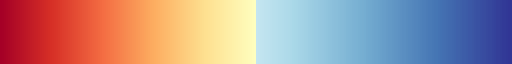

In [42]:
colors_bad= plt.cm.RdYlBu(np.linspace(0, 0.5, 256))
colors_good = plt.cm.RdYlBu(np.linspace(0.65, 1, 256))
all_colors = np.vstack((colors_bad, colors_good))
corr_map = mpl.colors.LinearSegmentedColormap.from_list(
    'corr_map', all_colors)
corr_map

In [46]:
column_names = df2.keys()

# Don't need to recreate every part of the table, just the main numbers, putting the proper cell colors in pace. 
# cmap = mpl.colormaps["RdYlBu"]
cmap = corr_map

# norm_corr = mpl.colors.Normalize(vmin=-1.25, vcenter=0.65, vmax=1.25)
norm_corr = mpl.colors.TwoSlopeNorm(vmin=-1.25, vcenter=0.65, vmax=1.25)
num_models = df2.shape[0]
cmip6_first=0
state_estimate_first = 0
mod_count = 0
print("\multicolumn{1}{l}{\\textbf{CMIP5}} \\\\ \midrule")
for m in range(0, num_models):
    mod_name = df2.index[m]
    if mod_name.startswith('bcc') | mod_name.startswith('GISS_E2_H_CC') | mod_name.startswith('GISS_E2_R_CC') | mod_name.startswith('EC_Earth3')  | mod_name.startswith('MIROC_ESM'):
        continue
    mod_values = df2.loc[mod_name,:].values
    mod_name_updated = mod_name.replace('_','-')
    if "-6" in mod_name_updated:
        mod_name_updated = mod_name_updated.replace('-6', ' (6)')
        if cmip6_first==0:
            cmip6_first=1
            print("\multicolumn{1}{l}{\\textbf{CMIP6}} \\\\ \midrule")
    if "SOSE" in mod_name_updated:
        if state_estimate_first==0:
            state_estimate_first=1
            print("\multicolumn{1}{l}{\\textbf{State Estimates}} \\\\ \midrule")
    mod_count = mod_count+1
    print('\\textbf{' + mod_name_updated + '} ', end='')
    for idx, val in enumerate(mod_values):
        if np.isnan(val):
            print('& ', end='')

            print( '-' , end='')
        elif idx+1==df2.shape[1]:
            continue # skip last column w/ T/B ratio, removing that from text
            print(str(val.round(1)) + ' ', end='')
        elif val.round(1)>=0.7:
            print('& ', end='')

            rgba_color = cmap(norm_corr(val),bytes=True) 
            
                
            r = rgba_color[0]/255
            g = rgba_color[1]/255
            b = rgba_color[2]/255
            print('\cellcolor[rgb]{' + str(r.round(3)) + ',' + str(g.round(3)) + ','  + str(b.round(3)) + '}' + '\\textbf{' + str(val.round(1)) + '} ', end='')

        else:
            print('& ', end='')

            rgba_color = cmap(norm_corr(val),bytes=True)

            r = rgba_color[0]/255
            g = rgba_color[1]/255
            b = rgba_color[2]/255
            print('\cellcolor[rgb]{' + str(r.round(3)) + ',' + str(g.round(3)) + ','  + str(b.round(3)) + '}' + str(val.round(1)) + ' ', end='')
    print('\\\\', end='')

    print('')

    # stats on whether a given change improved or worsened things

column_names = df2.keys()
print('\\\\   ', end='')

column_names.shape
# print("\midrule")
print('\\\\', end='')

# correlation >0.7:
for i in range(0, column_names.shape[0]-1):
    if i==0:
        print(" \\textbf{ \\# correlation $\geq$0.7 (\%)} " , end='')
    
    print('& ', end='')

    # print(column_names[i])
    n = sum(np.round(df2[column_names[i]].values,1)>=0.7)
    print(' \\textbf{' + str(n) + ' (' + str(int(np.round(n/mod_count*100,0))) + '\%)} ' , end='')
print('\\\\', end='')
print('')
# number improved
for i in range(0, column_names.shape[0]-1):
    
    if i==0:
        print(" \\textbf{ \\# improved} &  " , end='')
        continue
    print('& ', end='')

    # print(column_names[i])
    n = sum((df2[column_names[i]].values - df2[column_names[0]].values)>0)
    print(' \\textbf{' + str(n) + '} ' , end='')
print('\\\\', end='')
print('')

# number worsened
for i in range(0, column_names.shape[0]-1):
    
    if i==0:
        print(" \\textbf{ \\# worsened} &  " , end='')
        continue
    print('& ', end='')

    # print(column_names[i])
    n = sum((df2[column_names[i]].values - df2[column_names[0]].values)<0)
    print(' \\textbf{' + str(n) + '} ' , end='')
print('&', end='')



\multicolumn{1}{l}{\textbf{CMIP5}} \\ \midrule
\textbf{CESM1-BGC} & \cellcolor[rgb]{0.388,0.6,0.776}\textbf{1.0} & \cellcolor[rgb]{0.376,0.584,0.769}\textbf{1.0} & \cellcolor[rgb]{0.373,0.58,0.769}\textbf{1.0} & \cellcolor[rgb]{0.412,0.627,0.792}\textbf{0.9} & \cellcolor[rgb]{0.463,0.682,0.82}\textbf{0.9} & \cellcolor[rgb]{0.404,0.616,0.788}\textbf{1.0} & \cellcolor[rgb]{0.388,0.6,0.776}\textbf{1.0} & \cellcolor[rgb]{0.376,0.584,0.769}\textbf{1.0} & \cellcolor[rgb]{0.388,0.6,0.78}\textbf{1.0} & \cellcolor[rgb]{0.376,0.584,0.769}\textbf{1.0} \\
\textbf{CMCC-CESM} & \cellcolor[rgb]{0.902,0.314,0.208}-0.7 & \cellcolor[rgb]{0.969,0.525,0.306}-0.3 & \cellcolor[rgb]{0.914,0.341,0.224}-0.6 & \cellcolor[rgb]{0.992,0.698,0.396}-0.1 & \cellcolor[rgb]{0.396,0.608,0.78}\textbf{1.0} & \cellcolor[rgb]{0.878,0.267,0.188}-0.7 & \cellcolor[rgb]{0.886,0.286,0.196}-0.7 & \cellcolor[rgb]{0.871,0.247,0.18}-0.8 & \cellcolor[rgb]{0.38,0.592,0.773}\textbf{1.0} & \cellcolor[rgb]{0.376,0.584,0.769}\textbf{1.0} 

In [88]:
column_names = df2.keys()

column_names.shape
print("\midrule")
print('\\\\', end='')

for i in range(0, column_names.shape[0]):
    if i>0:
        print('& ', end='')

    # print(column_names[i])
    n = sum(np.round(df2[column_names[i]].values,1)>=0.7)
    print('textbf{' + str(n) + ' (' + str(int(np.round(n/mod_count*100,0))) + '%)} ' , end='')
print('\\\\', end='')


\midrule
\\textbf{11 (32%)} & textbf{11 (32%)} & textbf{18 (53%)} & textbf{29 (85%)} & textbf{15 (44%)} & textbf{9 (26%)} & textbf{10 (29%)} & textbf{5 (15%)} & textbf{34 (100%)} & textbf{34 (100%)} & textbf{30 (88%)} \\

In [77]:
i=2
sum(df2[column_names[i]].values - df2[column_names[0]].values>0)

27

In [30]:
i=0
sum(np.round(df2.orig_pco2_corr.values,1)>=0.7)

11

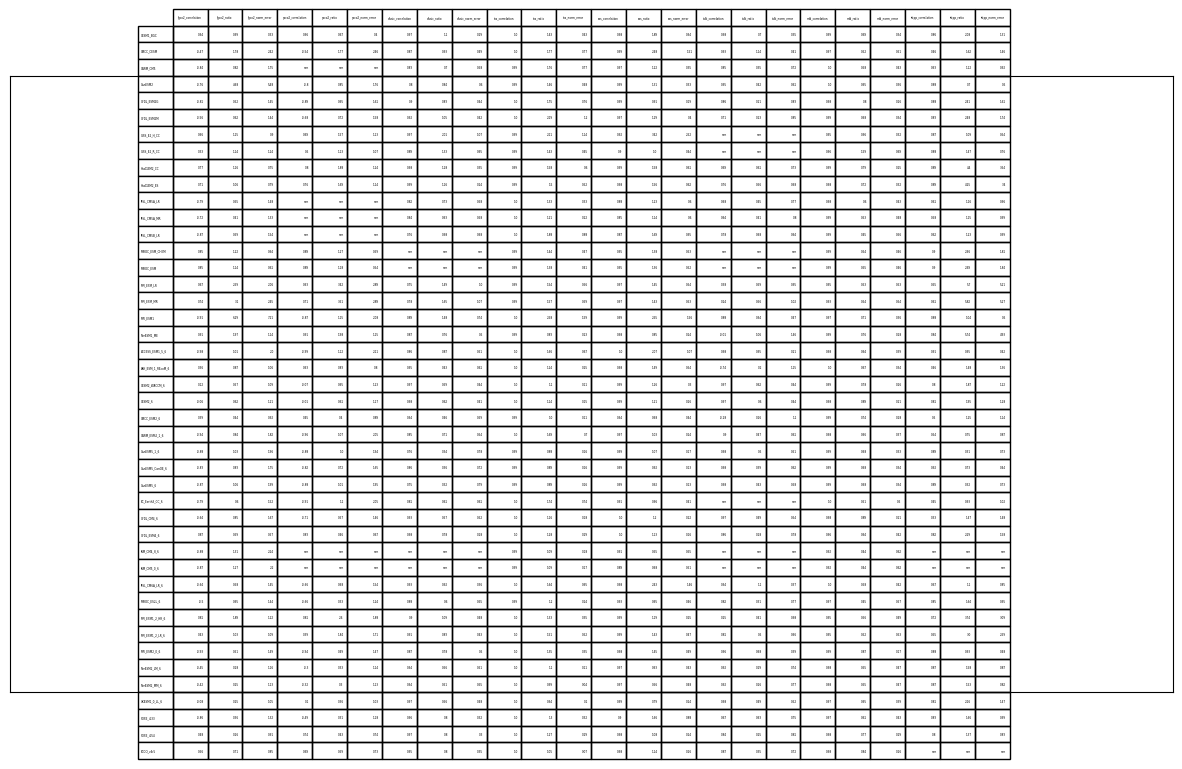

In [23]:
vals = np.around(df.values,2)
norm = plt.Normalize(vals.min()-1, vals.max()+1)
colours = plt.cm.hot(norm(vals))

fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111, frameon=True, xticks=[], yticks=[])

the_table=plt.table(cellText=vals, rowLabels=df.index, colLabels=df.columns, 
                    colWidths = [0.03]*vals.shape[1], loc='center', 
                    cellColours=colours)
plt.show()


In [13]:
df2

,orig_pco2_corr,dic_phase_adj_pco2_corr,dic_amp_adj_pco2_corr,dic_phase_amp_adj_pco2_corr,sst_amp_adj_pco2_corr,talk_phase_adj_pco2_corr,talk_amp_adj_pco2_corr,talk_phase_amp_adj_pco2_corr,dic_phase_amp_sst_phase_amp_adj_pco2_corr,dic_sst_ta_adj_pco2_corr,T_B_ratio
model_name,,,,,,,,,,,
CESM1_BGC,0.965699,0.974813,0.979593,0.943503,0.902399,0.951872,0.966156,0.976283,0.962127,0.976426,0.817705
CMCC_CESM,-0.669754,-0.330985,-0.614044,-0.071320,0.957598,-0.741077,-0.701888,-0.770307,0.969440,0.976429,1.704333
CanESM2,-0.723365,0.647783,-0.216878,0.970766,0.010546,-0.721851,-0.969400,-0.978585,0.910996,0.976651,1.047636
GFDL_ESM2G,-0.954629,-0.040368,-0.252077,0.789841,0.536070,-0.967218,-0.627944,-0.819089,0.920058,0.977784,1.295317
GFDL_ESM2M,-0.957454,0.061454,-0.933719,-0.074273,0.692887,-0.971267,-0.428686,-0.837027,0.926519,0.977936,1.221727
GISS_E2_H_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GISS_E2_R_CC,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HadGEM2_CC,0.916633,0.976505,0.782986,0.903719,0.974136,0.912103,0.855091,0.809690,0.969908,0.977291,0.736937
HadGEM2_ES,0.883382,0.972051,0.814301,0.937984,0.970152,0.876387,0.785939,0.723226,0.965414,0.977263,0.778118


In [16]:
# for each model present in both df and df2, save out both spco2 correlation values, then compare
df_comparison = pd.DataFrame(columns=['model', 'spco2_corr_df1', 'spco2_corr_df2'])
for m in range(0, len(df2.index.values)):
    mod_name = df2.index[m]
    if mod_name in df.index:
        spco2_corr_df1 = df.loc[mod_name,'spco2_correlation']
        spco2_corr_df2 = df2.loc[mod_name,'orig_pco2_corr']
        print(mod_name + ': ' + str(spco2_corr_df1) + ', ' + str(spco2_corr_df2))
        # save values along with model name into a new dataframe
        new_row = pd.DataFrame({'model': [mod_name], 'spco2_corr_df1': [spco2_corr_df1], 'spco2_corr_df2': [spco2_corr_df2]})
        df_comparison = pd.concat([df_comparison, new_row], ignore_index=True)

CESM1_BGC: 0.959114702260481, 0.965699258802647
CMCC_CESM: -0.541379299850222, -0.669754497823048
CanESM2: -0.80170245911252, -0.723364807061774
GFDL_ESM2G: -0.886443779862969, -0.954628980073582
GFDL_ESM2M: -0.677562026132837, -0.957454334313509
GISS_E2_H_CC: 0.693783613537664, nan
GISS_E2_R_CC: 0.499565669515578, nan
HadGEM2_CC: 0.801620647669471, 0.916633195420447
HadGEM2_ES: 0.75668869593997, 0.883382125504916
MIROC_ESM_CHEM: 0.894445915469658, nan
MIROC_ESM: 0.890162023906532, nan
MPI_ESM_LR: 0.631262149221505, 0.666192993813991
MPI_ESM_MR: 0.707547570696985, 0.725145258892347
MRI_ESM1: -0.869558765539195, -0.832298771589682
NorESM1_ME: 0.907827065887582, 0.936137516275401
ACCESS_ESM1_5_6: -0.987862698418821, -0.978960107407786
AWI_ESM_1_REcoM_6: 0.632877428251132, -0.0348470708344485
CESM2_WACCM_6: -0.0674497861525138, -0.0769962031259412
CESM2_6: -0.0111180921625103, -0.0177408672822936
CMCC_ESM2_6: 0.451409554167778, 0.479798618643304
CNRM_ESM2_1_6: -0.96485688420918, -0.953237

/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_59472/3402997972.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparison = pd.concat([df_comparison, new_row], ignore_index=True)


In [17]:
df_comparison

,model,spco2_corr_df1,spco2_corr_df2
0,CESM1_BGC,0.959115,0.965699
1,CMCC_CESM,-0.541379,-0.669754
2,CanESM2,-0.801702,-0.723365
3,GFDL_ESM2G,-0.886444,-0.954629
4,GFDL_ESM2M,-0.677562,-0.957454
5,GISS_E2_H_CC,0.693784,NaN
6,GISS_E2_R_CC,0.499566,NaN
7,HadGEM2_CC,0.801621,0.916633
8,HadGEM2_ES,0.756689,0.883382
9,MIROC_ESM_CHEM,0.894446,NaN


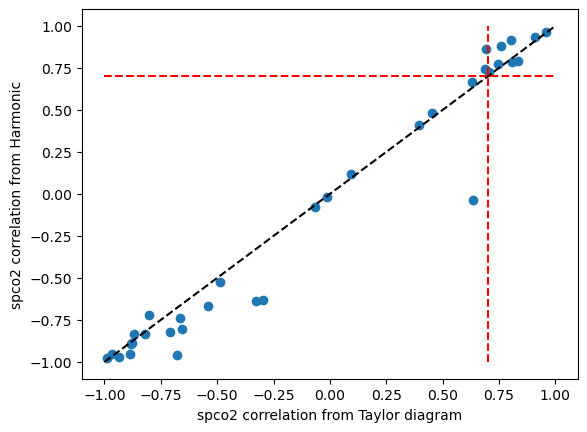

In [23]:
plt.scatter(df_comparison['spco2_corr_df1'], df_comparison['spco2_corr_df2'])
plt.xlabel('spco2 correlation from Taylor diagram')
plt.ylabel('spco2 correlation from Harmonic')
plt.plot([-1,1],[-1,1], 'k--')
plt.plot([.7, .7], [-1,1], 'r--')
plt.plot([-1,1], [.7, .7], 'r--')

In [41]:
df_comparison['model'][np.abs(df_comparison['spco2_corr_df1'] - df_comparison['spco2_corr_df2'])>0.4]

16    AWI_ESM_1_REcoM_6
Name: model, dtype: object

In [29]:
print(df_comparison['model'][df_comparison['spco2_corr_df1']>=0.65])
print(df_comparison['model'][df_comparison['spco2_corr_df2']>=0.65])


0            CESM1_BGC
5         GISS_E2_H_CC
7           HadGEM2_CC
8           HadGEM2_ES
9       MIROC_ESM_CHEM
10           MIROC_ESM
12          MPI_ESM_MR
14          NorESM1_ME
26         GFDL_ESM4_6
27       GISS_E2_1_G_6
30     MPI_ESM1_2_HR_6
37          BSOSE_i154
38    ECCO_v4r5_Darwin
Name: model, dtype: object
0            CESM1_BGC
7           HadGEM2_CC
8           HadGEM2_ES
11          MPI_ESM_LR
12          MPI_ESM_MR
14          NorESM1_ME
26         GFDL_ESM4_6
27       GISS_E2_1_G_6
30     MPI_ESM1_2_HR_6
37          BSOSE_i154
38    ECCO_v4r5_Darwin
Name: model, dtype: object
